Click "Copy to Drive" above to copy this file to your Colab account.


##7C Hyperparameter Classification

Preamble

In [ ]:
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn import metrics
from sklearn.metrics import classification_report

import matplotlib
import matplotlib.pyplot as plt

In [ ]:
# load dataset
df = pd.read_csv("https://raw.githubusercontent.com/DataAnalytics808/DASC-522-demo-repository/main/data/Diabetes.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.6,50,1
1,1,85,66,29,0,26.6,0.4,31,0
2,8,183,64,0,0,23.3,0.7,32,1
3,1,89,66,23,94,28.1,0.2,21,0
4,0,137,40,35,168,43.1,2.3,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.2,63,0
764,2,122,70,27,0,36.8,0.3,27,0
765,5,121,72,23,112,26.2,0.2,30,0
766,1,126,60,0,0,30.1,0.3,47,1


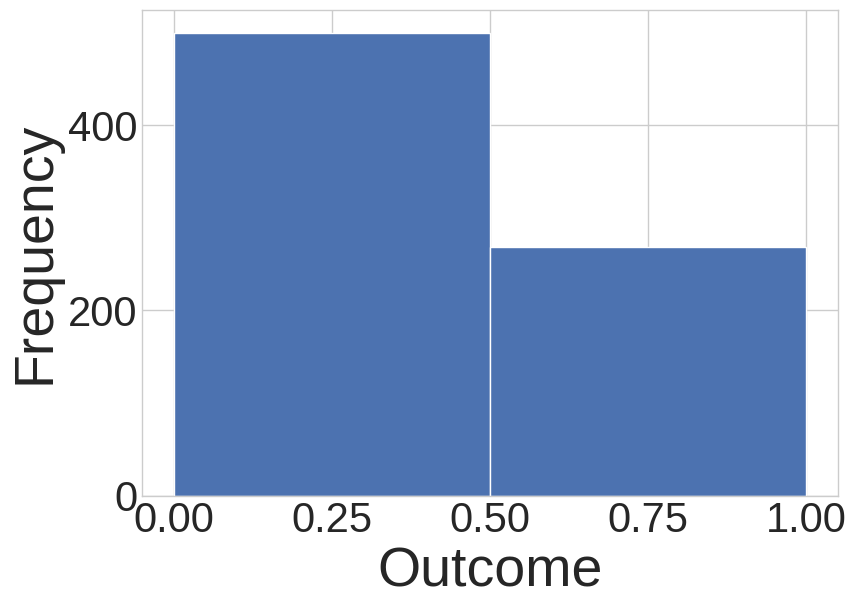

In [ ]:
fig = plt.figure(figsize=(8,6))
plt.hist(df['Outcome'], bins=2)
plt.xlabel('Outcome')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


# # split into input (X) and output (Y) variables
X = df.drop(columns='Outcome')
y = df['Outcome']


# Split into test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

X_train


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
34,10,122,78,31,0,27.6,0.5,45
221,2,158,90,0,0,31.6,0.8,66
531,0,107,76,0,0,45.3,0.7,24
518,13,76,60,0,0,32.8,0.2,41
650,1,91,54,25,100,25.2,0.2,23
...,...,...,...,...,...,...,...,...
628,5,128,80,0,0,34.6,0.1,45
456,1,135,54,0,0,26.7,0.7,62
398,3,82,70,0,0,21.1,0.4,25
6,3,78,50,32,88,31.0,0.2,26


###Data understanding

In [ ]:

# ------ Common formating options ---------
plt.style.use('seaborn-v0_8-whitegrid')

SMALL_SIZE = 20
MEDIUM_SIZE = 30
BIGGER_SIZE = 40

plt.rc('font', size=SMALL_SIZE)           # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)      # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=20)    # legend fontsize
plt.rc('legend', title_fontsize=20)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)   # fontsize of the figure title

plt.rcParams["figure.figsize"] = (15,10)
# ------ end format ---------


Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age
Outcome


/tmp/ipykernel_26365/3542506921.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column,hue='Outcome', multiple = 'stack', alpha=.2)


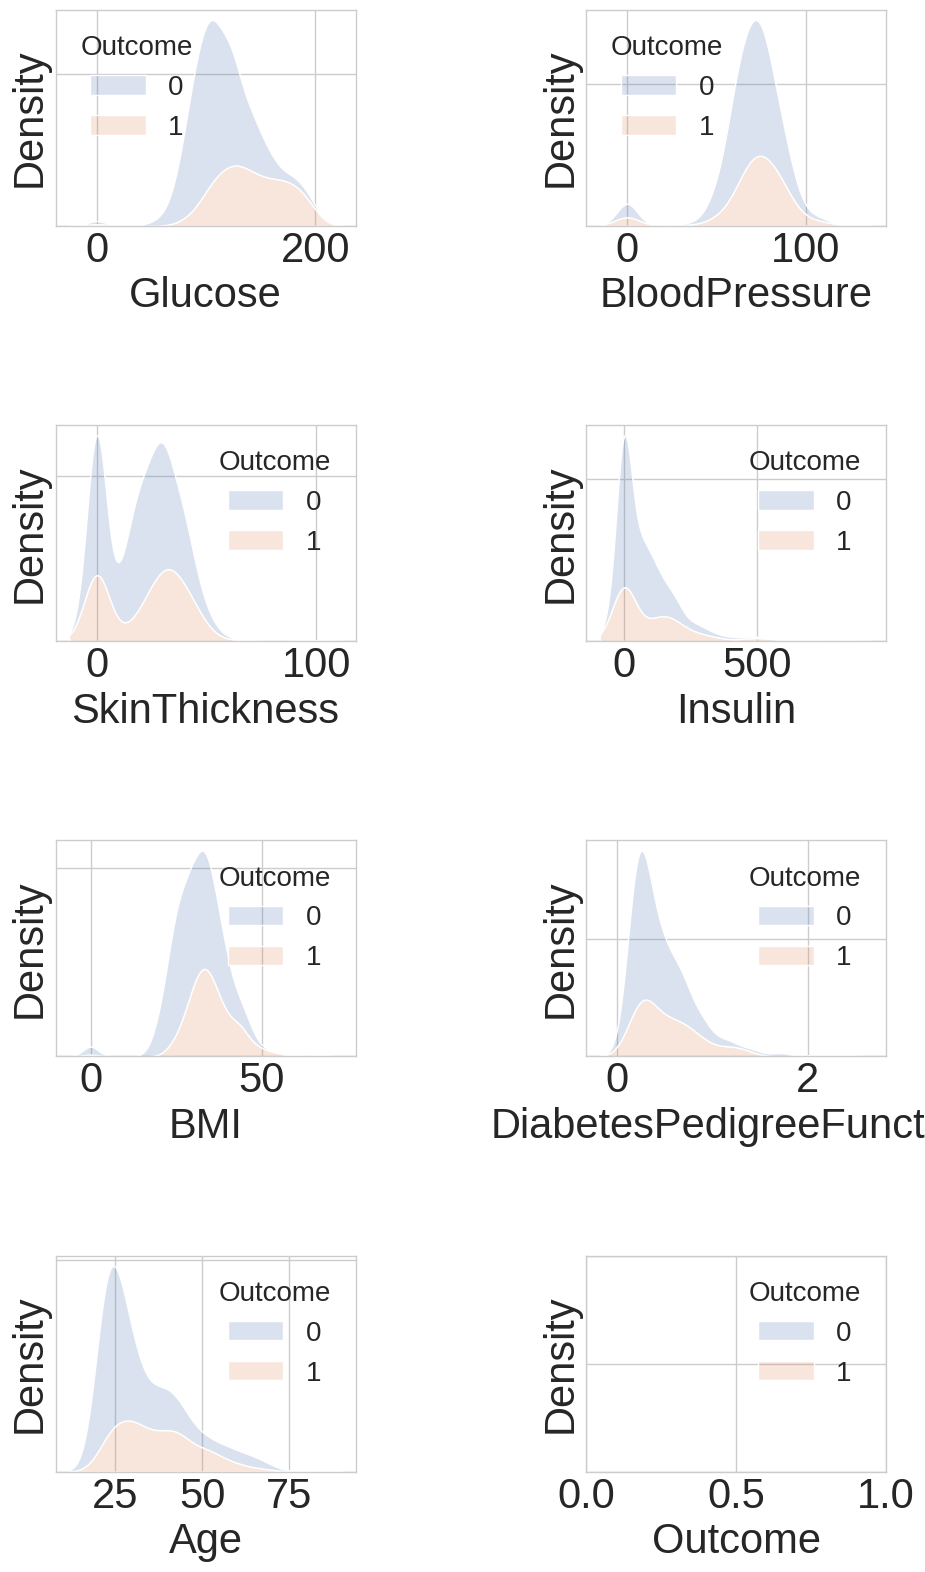

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(4,2, figsize=(12, 18))
fig.tight_layout(pad=5)

for i, column in enumerate(df.columns, 1):
    print(column)
    if i>1:
      plt.subplot(4,2,i-1)
      sns.kdeplot(data=df, x=column,hue='Outcome', multiple = 'stack', alpha=.2)

      ax2 = plt.gca()
      ax2.yaxis.set_tick_params(labelleft=False)

Define helper functions

In [ ]:
def evaluate_model(model, x_test, y_test):

    # Predict Test Data
    y_pred = np.round(model.predict(x_test))
    # Calculate accuracy, precision, recall, f1-score, and kappa score
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred, average='macro')
    rec = metrics.recall_score(y_test, y_pred, average='macro')
    f1 = metrics.f1_score(y_test, y_pred, average='macro')
    cm = metrics.confusion_matrix(y_test, y_pred)

    # return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm, 'y_pred':y_pred}
    return acc

def plot_acc(fit1):
		plt.rcParams["figure.figsize"] = (8,8)
		plt.plot(fit1.history['accuracy'], label='Training accuracy')
		plt.plot(fit1.history['val_accuracy'], label='Validation accuracy')

		# plt.ylim([0, y_lim])
		plt.xlabel('Epoch')
		plt.ylabel('accuracy')
		plt.legend()
		plt.title(f'Neurons = {num_neurons}')
		plt.grid(True)
		plt.show()



###Create normalizer

In [ ]:
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Normalization # Import Normalization from the correct location

# Normalizer: a stubborn error occurs if a dataframe is fed into .adapt.
# Must convert to numpy array with X.values
# The dataframe version of X is still used to train the NN
X_values = X.values
number_of_inputs= X_values.shape[1]
normalizer = Normalization(input_shape=[number_of_inputs,])
normalizer.adapt(X_values)


# Display the values that the normalizer will multiply each column by
means     = normalizer.mean.numpy().flatten()
variances = normalizer.variance.numpy().flatten()
stddevs   = np.sqrt(variances)  # standard deviation is the square root of variance

# Display the formatted string showing column names and normalization values
for column, mean, std in zip(X_train.columns, means, stddevs):
    print(f"Column '{column}': subtract mean {mean:.4f}, divide by std {std:.4f}")


Column 'Pregnancies': subtract mean 3.8451, divide by std 3.3674
Column 'Glucose': subtract mean 120.8945, divide by std 31.9518
Column 'BloodPressure': subtract mean 69.1055, divide by std 19.3432
Column 'SkinThickness': subtract mean 20.5365, divide by std 15.9418
Column 'Insulin': subtract mean 79.7995, divide by std 115.1689
Column 'BMI': subtract mean 31.9926, divide by std 7.8790
Column 'DiabetesPedigreeFunction': subtract mean 0.4719, divide by std 0.3311
Column 'Age': subtract mean 33.2409, divide by std 11.7526


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


###Create model with hp sweep

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.6692 - loss: 0.6282 - val_accuracy: 0.7037 - val_loss: 0.6879
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7040 - loss: 0.6198 - val_accuracy: 0.6963 - val_loss: 0.6804
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7065 - loss: 0.6127 - val_accuracy: 0.6741 - val_loss: 0.6736
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7015 - loss: 0.6068 - val_accuracy: 0.6815 - val_loss: 0.6667
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7015 - loss: 0.6007 - val_accuracy: 0.6889 - val_loss: 0.6609
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7040 - loss: 0.5957 - val_accuracy: 0.6741 - val_loss: 0.6548
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7065 - loss: 0.5904 - val_accuracy: 0.6667 - val_loss: 0.6497
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7139 - loss: 0.5861 - val_accuracy: 0.6741 - val_loss: 0.6448
E

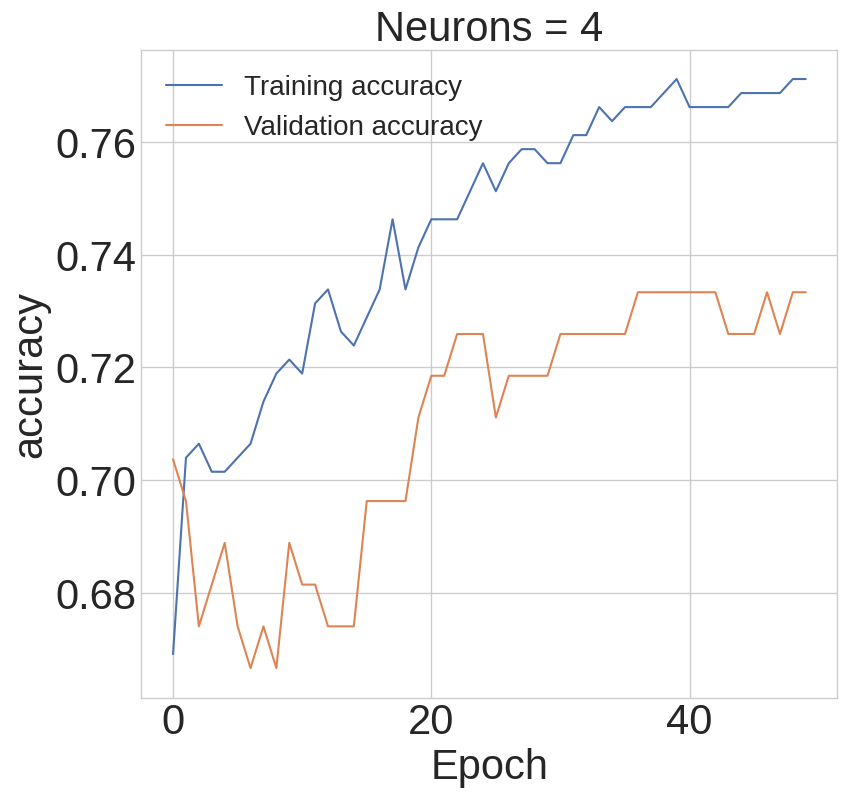

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.5717 - loss: 0.7692 - val_accuracy: 0.5259 - val_loss: 0.7714
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5896 - loss: 0.7534 - val_accuracy: 0.5333 - val_loss: 0.7576
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6468 - loss: 0.7395 - val_accuracy: 0.6222 - val_loss: 0.7448
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6791 - loss: 0.7277 - val_accuracy: 0.6667 - val_loss: 0.7332
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6965 - loss: 0.7165 - val_accuracy: 0.6889 - val_loss: 0.7236
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7214 - loss: 0.7068 - val_accuracy: 0.7185 - val_loss: 0.7129
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7214 - loss: 0.6958 - val_accuracy: 0.7333 - val_loss: 0.7045
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7289 - loss: 0.6862 - val_accuracy: 0.7407 - val_loss: 0

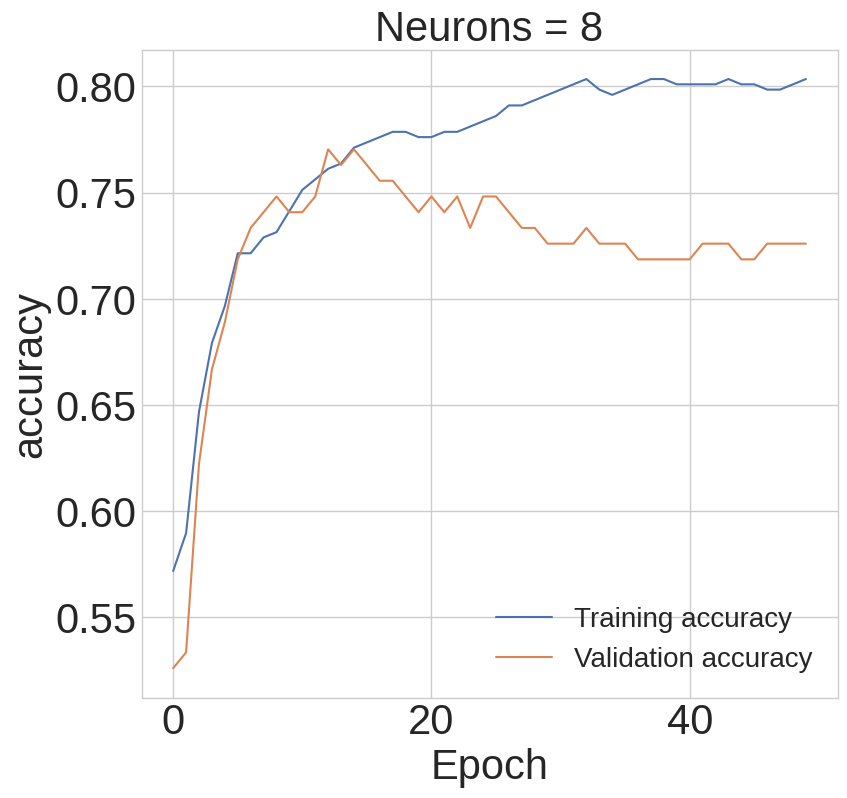

In [ ]:
my_initial_lrate = 0.001

# create blank lists to store metrics
acc_list = []
val_acc_list = []
f1_0_test_list = []
f1_1_test_list = []

METRICS = [tf.keras.metrics.BinaryAccuracy(name='accuracy', threshold=0.5)]

# sweep neurons
# neurons_to_try = [30,40,50, 70, 110]
neurons_to_try = [4,8]

for num_neurons in neurons_to_try:

  #---- model
  model = keras.Sequential([normalizer,
                            layers.Dense(num_neurons, activation='relu', input_dim=number_of_inputs, kernel_regularizer=regularizers.l2(0.005)),
                            layers.Dense(num_neurons, activation='relu',                             kernel_regularizer=regularizers.l2(0.005)),
                            layers.Dense(1, activation='sigmoid') ])

  model.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(my_initial_lrate),
                metrics=METRICS)


  history = model.fit(X_train, y_train,
                      epochs=50,
                      validation_split = 0.25,           # Calculate validation results on 20% of the training data
                      # class_weight = {0:1, 1:5.3636},
                      verbose=1 )

  #---- end model

  # plot history curves
  plot_acc(history)

###add metrics

In [ ]:
print(np.unique(y_train))

[0 1]


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.5373 - loss: 1.1722 - val_accuracy: 0.5778 - val_loss: 0.7273
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5050 - loss: 1.1451 - val_accuracy: 0.5630 - val_loss: 0.7211
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5100 - loss: 1.1231 - val_accuracy: 0.5481 - val_loss: 0.7164
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4975 - loss: 1.1017 - val_accuracy: 0.5333 - val_loss: 0.7129
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 1.0854 - val_accuracy: 0.5037 - val_loss: 0.7097
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4975 - loss: 1.0697 - val_accuracy: 0.5037 - val_loss: 0.7075
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4751 - loss: 1.0568 - val_accuracy: 0.4815 - val_loss: 0.7057
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4726 - loss: 1.0453 - val_accuracy: 0.4815 - val_loss: 0.7043
E

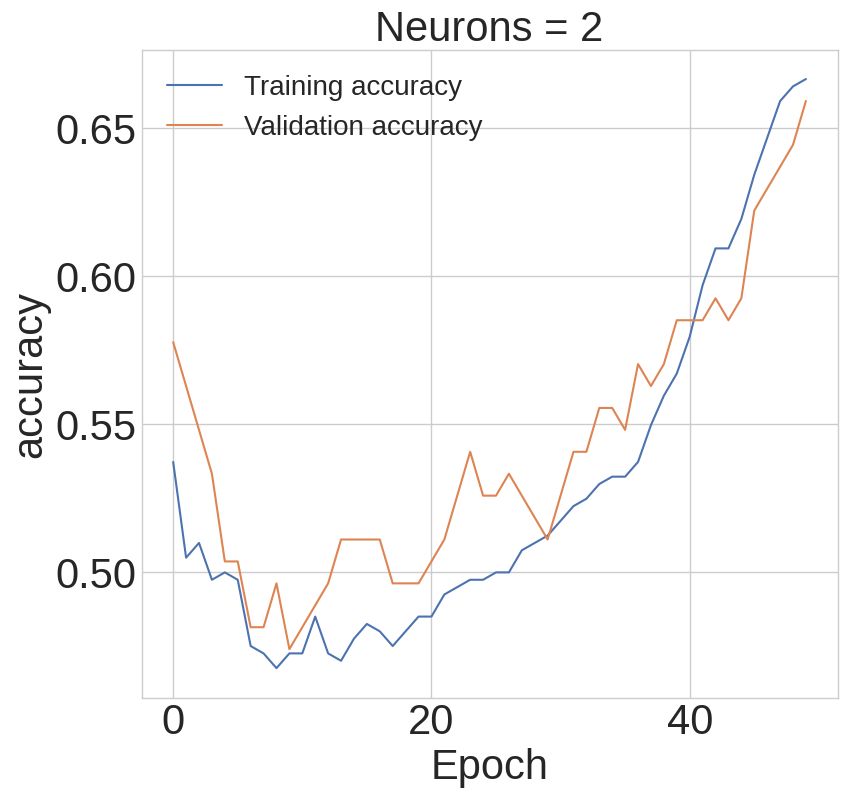

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

---Train Set Confusion Matrix & Classification Report
[[222 128]
 [ 51 136]]
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       350
           1       0.52      0.73      0.60       187

    accuracy                           0.67       537
   macro avg       0.66      0.68      0.66       537
weighted avg       0.71      0.67      0.67       537

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

---Test Set Confusion Matrix & Classification Report
[[91 59]
 [18 63]]
              precision    recall  f1-score   support

           0       0.83      0.61      0.70       150
           1       0.52      0.78      0.62        81

    accuracy                           0.67       231
   macro avg       0.68      0.69      0.66       231
weighted avg       0.72      0.67      0.67       231

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.6406 - loss: 1.1292 - val_accuracy: 0.6667 - val_loss: 0.6654
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6443 - loss: 1.0855 - val_accuracy: 0.6667 - val_loss: 0.6586
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6542 - loss: 1.0521 - val_accuracy: 0.6667 - val_loss: 0.6532
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6418 - loss: 1.0240 - val_accuracy: 0.6741 - val_loss: 0.6495
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6443 - loss: 0.9987 - val_accuracy: 0.6667 - val_loss: 0.6474
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6443 - loss: 0.9769 - val_accuracy: 0.6889 - val_loss: 0.6461
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6443 - loss: 0.9581 - val_accuracy: 0.7037 - val_loss: 0.6452
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6418 - loss: 0.9414 - val_accuracy: 0.7037 - val_loss: 0.6445
E

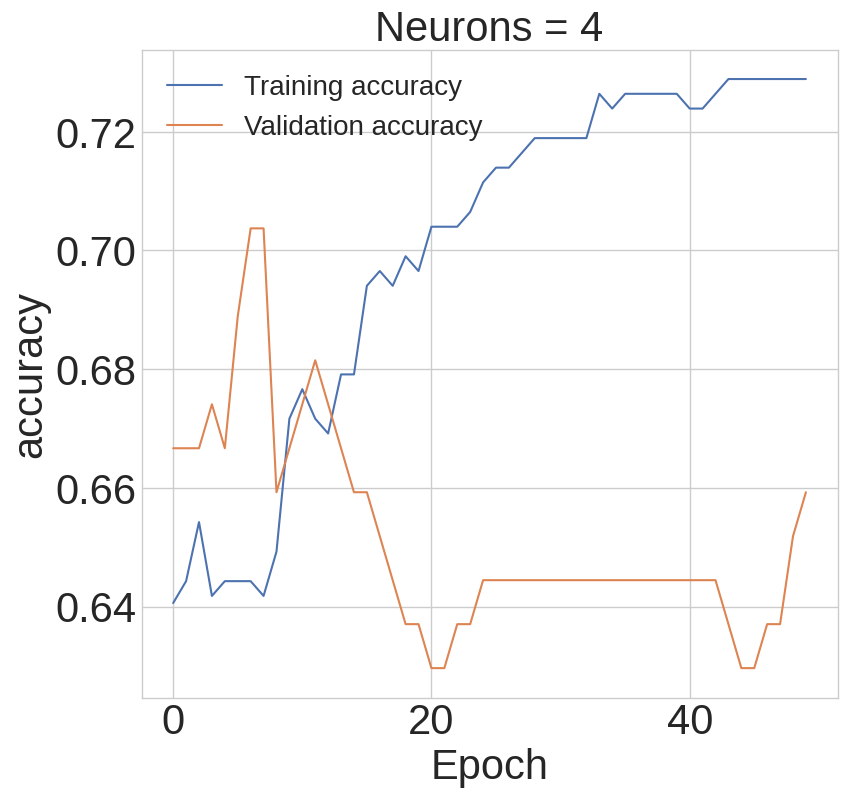

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

---Train Set Confusion Matrix & Classification Report
[[222 128]
 [ 27 160]]
              precision    recall  f1-score   support

           0       0.89      0.63      0.74       350
           1       0.56      0.86      0.67       187

    accuracy                           0.71       537
   macro avg       0.72      0.74      0.71       537
weighted avg       0.77      0.71      0.72       537

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

---Test Set Confusion Matrix & Classification Report
[[104  46]
 [ 14  67]]
              precision    recall  f1-score   support

           0       0.88      0.69      0.78       150
           1       0.59      0.83      0.69        81

    accuracy                           0.74       231
   macro avg       0.74      0.76      0.73       231
weighted avg       0.78      0.74      0.75       231

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.5531 - loss: 0.9677 - val_accuracy: 0.5407 - val_loss: 0.7612
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5547 - loss: 0.9502 - val_accuracy: 0.5481 - val_loss: 0.7561
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5672 - loss: 0.9359 - val_accuracy: 0.5556 - val_loss: 0.7491
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5771 - loss: 0.9222 - val_accuracy: 0.5926 - val_loss: 0.7434
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5945 - loss: 0.9086 - val_accuracy: 0.6222 - val_loss: 0.7349
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6294 - loss: 0.8959 - val_accuracy: 0.6222 - val_loss: 0.7281
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6443 - loss: 0.8829 - val_accuracy: 0.6519 - val_loss: 0.7221
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6741 - loss: 0.8709 - val_accuracy: 0.6593 - val_loss: 0.7163
E

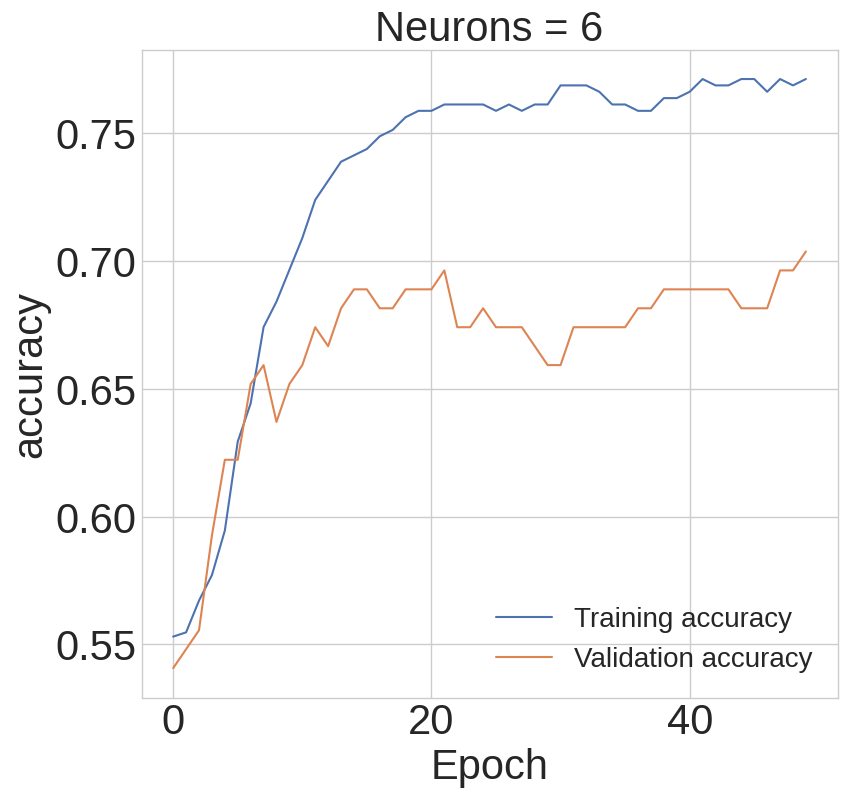

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

---Train Set Confusion Matrix & Classification Report
[[252  98]
 [ 34 153]]
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       350
           1       0.61      0.82      0.70       187

    accuracy                           0.75       537
   macro avg       0.75      0.77      0.75       537
weighted avg       0.79      0.75      0.76       537

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

---Test Set Confusion Matrix & Classification Report
[[115  35]
 [ 19  62]]
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       150
           1       0.64      0.77      0.70        81

    accuracy                           0.77       231
   macro avg       0.75      0.77      0.75       231
weighted avg       0.78      0.77      0.77       231

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5363 - loss: 1.0350 - val_accuracy: 0.4815 - val_loss: 0.7706
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4801 - loss: 1.0213 - val_accuracy: 0.4815 - val_loss: 0.7650
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5174 - loss: 1.0083 - val_accuracy: 0.4963 - val_loss: 0.7618
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5274 - loss: 0.9963 - val_accuracy: 0.5111 - val_loss: 0.7599
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5423 - loss: 0.9841 - val_accuracy: 0.5111 - val_loss: 0.7577
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5522 - loss: 0.9733 - val_accuracy: 0.4963 - val_loss: 0.7539
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5647 - loss: 0.9627 - val_accuracy: 0.5111 - val_loss: 0.7516
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5721 - loss: 0.9522 - val_accuracy: 0.5037 - val_loss: 0.7501
E

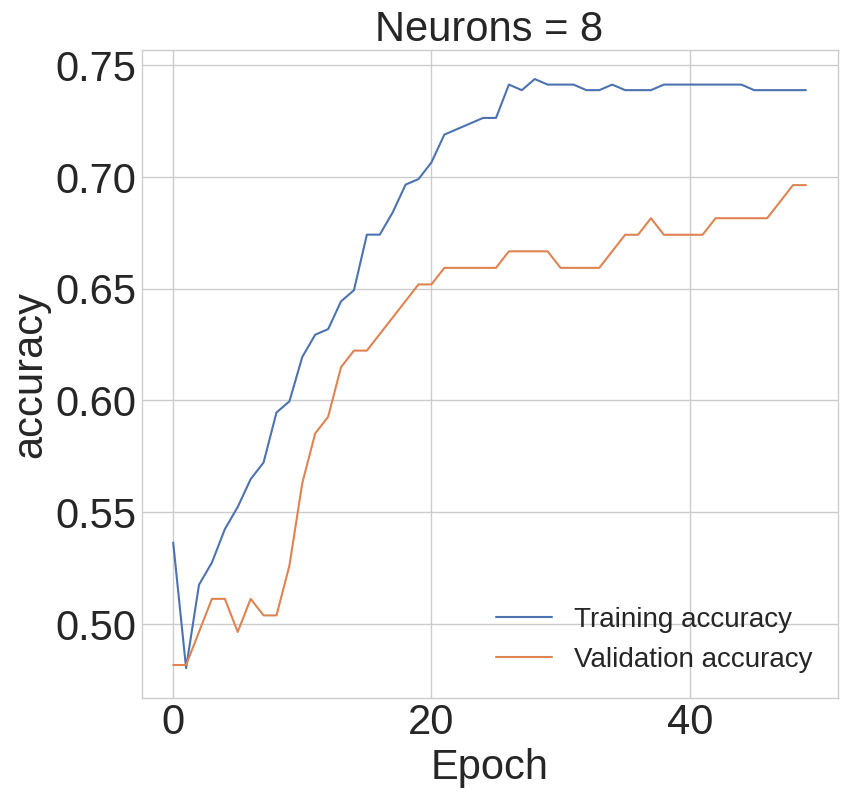

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

---Train Set Confusion Matrix & Classification Report
[[238 112]
 [ 34 153]]
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       350
           1       0.58      0.82      0.68       187

    accuracy                           0.73       537
   macro avg       0.73      0.75      0.72       537
weighted avg       0.77      0.73      0.73       537

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

---Test Set Confusion Matrix & Classification Report
[[107  43]
 [ 13  68]]
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       150
           1       0.61      0.84      0.71        81

    accuracy                           0.76       231
   macro avg       0.75      0.78      0.75       231
weighted avg       0.79      0.76      0.76       231

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.4786 - loss: 1.0457 - val_accuracy: 0.4074 - val_loss: 0.8357
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4378 - loss: 1.0137 - val_accuracy: 0.4222 - val_loss: 0.8300
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4577 - loss: 0.9888 - val_accuracy: 0.4296 - val_loss: 0.8240
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4925 - loss: 0.9661 - val_accuracy: 0.4296 - val_loss: 0.8191
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5124 - loss: 0.9477 - val_accuracy: 0.4370 - val_loss: 0.8168
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5473 - loss: 0.9309 - val_accuracy: 0.4444 - val_loss: 0.8118
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5771 - loss: 0.9149 - val_accuracy: 0.4963 - val_loss: 0.8071
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6169 - loss: 0.9015 - val_accuracy: 0.5481 - val_loss: 0.8032
E

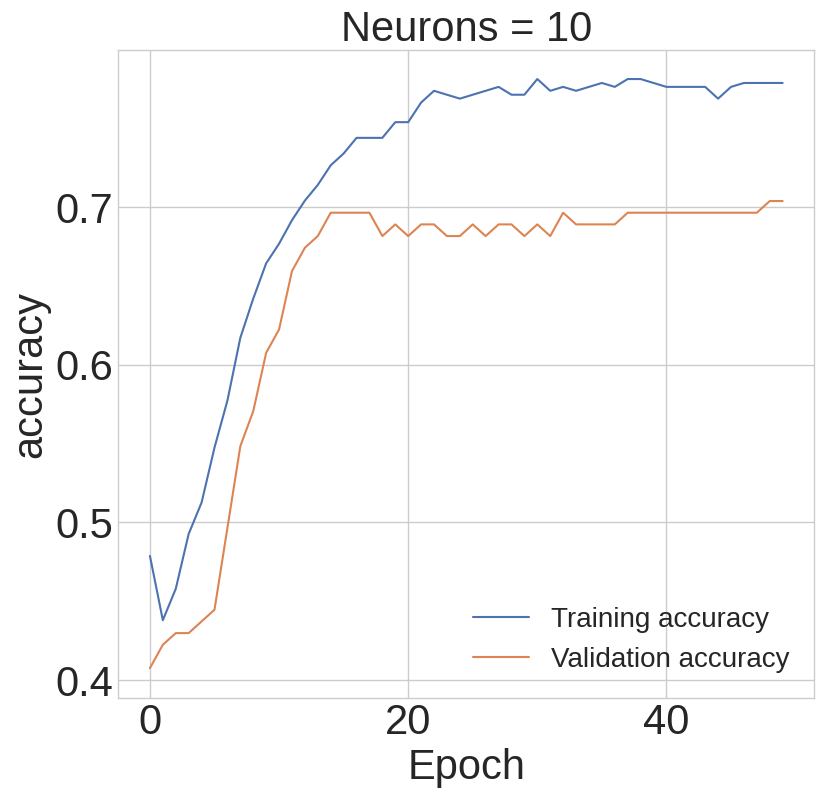

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

---Train Set Confusion Matrix & Classification Report
[[259  91]
 [ 38 149]]
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       350
           1       0.62      0.80      0.70       187

    accuracy                           0.76       537
   macro avg       0.75      0.77      0.75       537
weighted avg       0.78      0.76      0.76       537

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

---Test Set Confusion Matrix & Classification Report
[[117  33]
 [ 16  65]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       150
           1       0.66      0.80      0.73        81

    accuracy                           0.79       231
   macro avg       0.77      0.79      0.78       231
weighted avg       0.80      0.79      0.79       231



In [ ]:
my_initial_lrate = 0.001

# create blank lists to store metrics
acc_list = []
val_acc_list = []
f1_0_test_list = []
f1_1_test_list = []

METRICS = [tf.keras.metrics.BinaryAccuracy(name='accuracy', threshold=0.5)]

# sweep neurons
neurons_to_try = [2,4,6,8,10]
# neurons_to_try = [4,8]

for num_neurons in neurons_to_try:

  #---- model
  model = keras.Sequential([normalizer,
                            layers.Dense(num_neurons, activation='relu', input_dim=number_of_inputs, kernel_regularizer=regularizers.l2(0.005)),
                            layers.Dense(num_neurons, activation='relu',                             kernel_regularizer=regularizers.l2(0.005)),
                            layers.Dense(1, activation='sigmoid') ])

  model.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(my_initial_lrate),
                metrics=METRICS)


  history = model.fit(X_train, y_train.values,
                      epochs=50,
                      validation_split = 0.25,           # Calculate validation results on 20% of the training data
                      class_weight = {0: 1, 1: 2},
                      verbose=1 )

  #---- end model


  # calculate metrics from the final model (may be different from
  # history if early stopping used)

  # Isolate the accuracy metrics
  acc_list.append(evaluate_model(model, X_train, y_train))
  val_acc_list.append(evaluate_model(model, X_test, y_test))

  # Isolate f1 metrics
  y_pred = model.predict(X_test) > 0.5
  CR_as_dict = classification_report(y_test,y_pred, output_dict=True)
  f1_0_test_list.append(CR_as_dict['0']['f1-score'])
  f1_1_test_list.append(CR_as_dict['1']['f1-score'])

  # plot history curves
  plot_acc(history)

  y_pred = model.predict(X_train) > 0.5

  #Train Set Confusion Matrix
  print("\n---Train Set Confusion Matrix & Classification Report")
  confusion_matrix = metrics.confusion_matrix(y_train, y_pred)
  print(confusion_matrix)

  #Classification Report
  from sklearn.metrics import classification_report
  print(classification_report(y_train, y_pred))


  y_pred = model.predict(X_test) > 0.5

  #test Set Confusion Matrix
  print("\n---Test Set Confusion Matrix & Classification Report")
  confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
  print(confusion_matrix)

  #Classification Report
  from sklearn.metrics import classification_report
  print(classification_report(y_test, y_pred))

###Plot sweep results

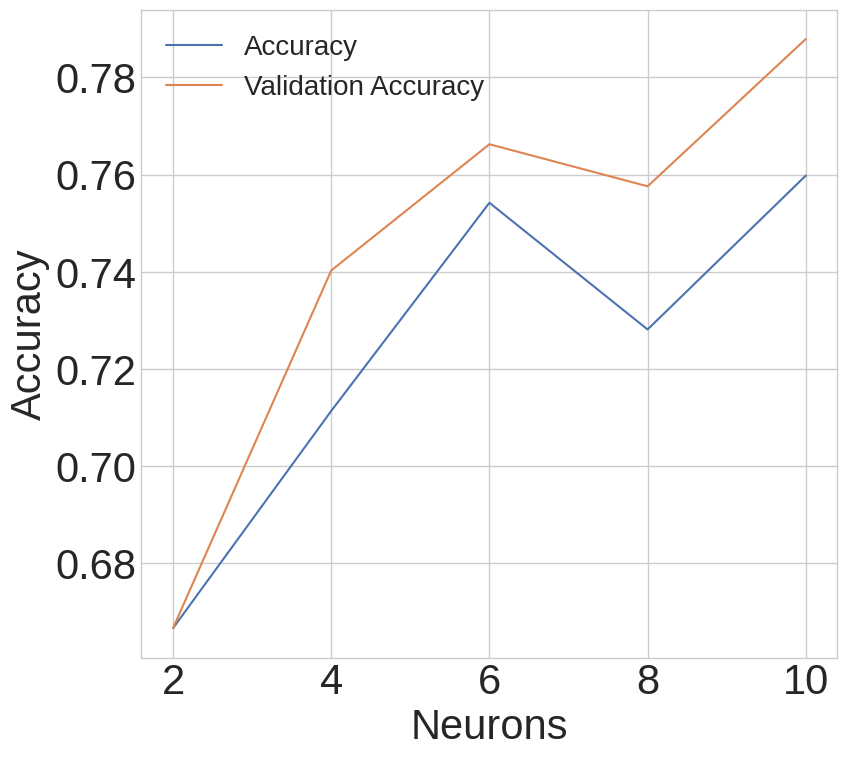

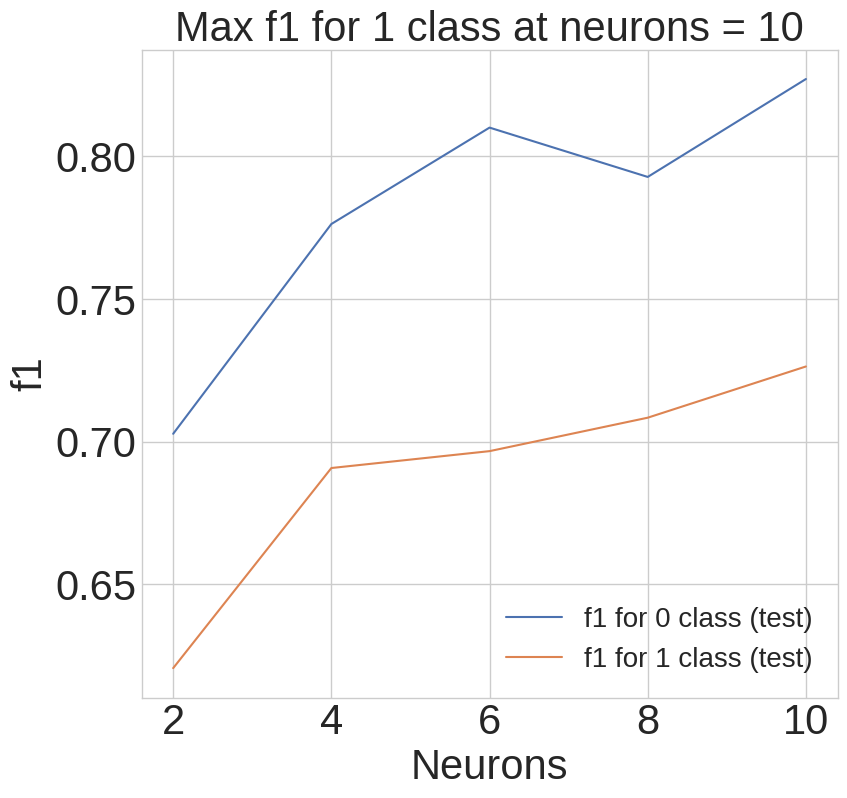

In [ ]:

#plot accuracy results
plt.plot(neurons_to_try, acc_list, label='Accuracy')
plt.plot(neurons_to_try, val_acc_list, label='Validation Accuracy')
# plt.ylim([1,y_lim])
plt.xlabel('Neurons')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


#plot f1 results
plt.plot(neurons_to_try, f1_0_test_list, label='f1 for 0 class (test)')
plt.plot(neurons_to_try, f1_1_test_list, label='f1 for 1 class (test)')

# plt.ylim([1,y_lim])
plt.xlabel('Neurons')
plt.ylabel('f1')
plt.legend()
plt.grid(True)

# find best weight
max_index = f1_1_test_list.index(max(f1_1_test_list))
max_wait  = neurons_to_try[max_index]

plt.title(f"Max f1 for 1 class at neurons = {max_wait}")
plt.show()
